In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import copy
from astropy.time import Time
import numpy as np
import os

from orbitalsim import diagnostic_calculators
from orbitalsim.universal_constants import UniversalConstants
from orbitalsim.celestial_body import CelestialBody
from orbitalsim.planets import Planets
from orbitalsim.diagnostic_calculators import *
from orbitalsim.simulation import NBodySimulation
from orbitalsim.set_positions import PositionsSetter

from orbitalsim.integrators.symplectic_euler import SymplecticEulerIntegrator
from orbitalsim.integrators.yoshida_4th_order import Yoshida4thOrderIntegrator
from orbitalsim.integrators.forward_euler import ForwardEuler
from orbitalsim.integrators.runge_kutta_4 import RungeKutta4Integrator
from orbitalsim.integrators.velocity_verlet import VelocityVerletIntegrator

from notebooks.results import *

In [ ]:
os.makedirs("results",exist_ok=True)

In [ ]:
import urllib.request

url = "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc"
urllib.request.urlretrieve(url, "../pck00010.tpc")
print("Downloaded successfully!")

url = "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de431.tpc"
urllib.request.urlretrieve(url, "../gm_de431.tpc")
print("Downloaded successfully!")

In [ ]:
class SimulationRunner:

    integrator = RungeKutta4Integrator()

    sun = CelestialBody(1.989e30, np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, 0.0]), name="Sun")

    all_bodies = copy.deepcopy(Planets().allPlanets)
    all_bodies.append(sun)

    center_of_mass = sum(body.mass * body.position for body in all_bodies) / sum(body.mass for body in all_bodies)

    for body in all_bodies:
        body.position = body.position - center_of_mass

    total_momentum = sum(body.mass * body.velocity for body in all_bodies)

    for body in all_bodies:
        if body.name == "Sun":
            body.velocity = body.velocity - total_momentum / body.mass

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(2000, 500)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()


In [ ]:
class SimulationDebugRunner:

    sun = CelestialBody(1.32712440018e20 / UniversalConstants.G, np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, 0.0]), name="Sun", horizons_id='10')

    all_bodies = copy.deepcopy(Planets().allPlanets)
    all_bodies.append(sun)

    center_of_mass = sum(body.mass * body.position for body in all_bodies) / sum(body.mass for body in all_bodies)

    for body in all_bodies:
        body.position = body.position - center_of_mass

    total_momentum = sum(body.mass * body.velocity for body in all_bodies)

    for body in all_bodies:
        if body.name == "Sun":
            body.velocity = body.velocity - total_momentum / body.mass

    start_time = "2000-01-01 00:00:00"
    epoch = Time(start_time).tdb.jd
    PositionsSetter.set_positions_at_time(all_bodies,epoch)

    # print(diagnostic_calculators.two_simulation_position_comparison(all_bodies, 50000, Yoshida4thOrderIntegrator(), RungeKutta4Integrator(), 10000, 100))

    print(diagnostic_calculators.horizon_data_position_comparison(all_bodies, start_time, 2000, RungeKutta4Integrator(), 10))

149600449309.49


C:\Users\willi\PycharmProjects\PhysicsSimulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


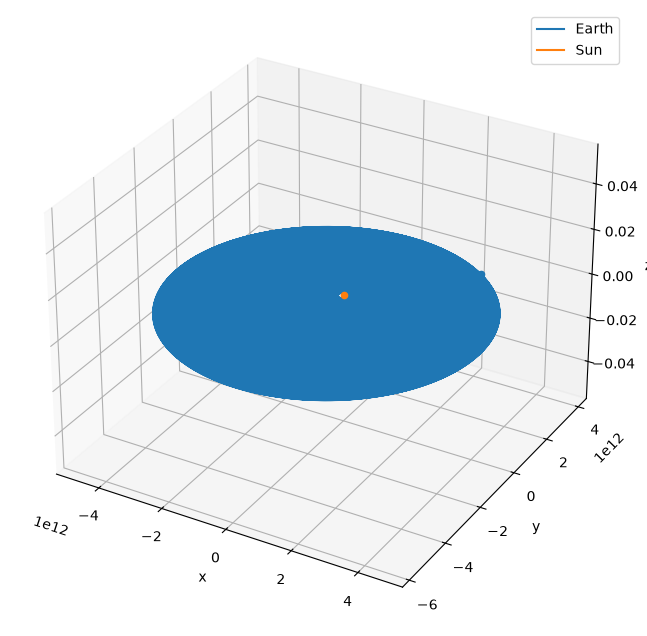

C:\Users\willi\PycharmProjects\PhysicsSimulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 1000x800 with 1 Axes>

C:\Users\willi\PycharmProjects\PhysicsSimulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

...

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 1000x800 with 1 Axes>

C:\Users\willi\PycharmProjects\PhysicsSimulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 1000x800 with 1 Axes>

In [9]:
class TwoBodyEarthSunComparison:

    integrator = ForwardEuler()
    dt = 50000

    sun = CelestialBody(1.32712440018e20 / UniversalConstants.G, np.array([-4.4930949e5, 0.0, 0.0]), np.array([0.0, -0.0895, 0.0]), name="Sun", horizons_id='10')
    earth = copy.deepcopy(Planets().earth)
    r = np.linalg.norm(earth.position - sun.position)
    earth.velocity = sun.velocity + np.array([0.0, Planets.true_circular_velocities(r, earth.mass, sun.mass), 0.0])
    all_bodies = [earth, copy.deepcopy(sun)]

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(50000000, dt)

    r = np.linalg.norm(traj[0, 0] - traj[0, 1])

    print(r)

    orbital_period = 2 * np.pi * np.sqrt(r**3 / (UniversalConstants.G * (all_bodies[0].mass + all_bodies[1].mass)))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

    df = diagnostic_calculators.analyze_two_body(traj, saved_velocities, simulation.bodies, dt, orbital_period)
    df.to_csv("results/forward_euler_diagnostics_v2.csv", index=False)

    integrator = SymplecticEulerIntegrator()

    earth = copy.deepcopy(Planets().earth)
    r = np.linalg.norm(earth.position - sun.position)
    earth.velocity = sun.velocity + np.array([0.0, Planets.true_circular_velocities(r, earth.mass, sun.mass), 0.0])
    all_bodies = [earth, copy.deepcopy(sun)]

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(50000000, dt)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

    df = diagnostic_calculators.analyze_two_body(traj, saved_velocities, simulation.bodies, dt, orbital_period)
    df.to_csv("results/symplectic_euler_diagnostics_v2.csv", index=False)

    integrator = RungeKutta4Integrator()

    earth = copy.deepcopy(Planets().earth)
    r = np.linalg.norm(earth.position - sun.position)
    earth.velocity = sun.velocity + np.array([0.0, Planets.true_circular_velocities(r, earth.mass, sun.mass), 0.0])
    all_bodies = [earth, copy.deepcopy(sun)]

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(50000000, dt)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

    df = diagnostic_calculators.analyze_two_body(traj, saved_velocities, simulation.bodies, dt, orbital_period)
    df.to_csv("results/runge_kutta_4_diagnostics_v2.csv", index=False)

    integrator = VelocityVerletIntegrator()

    earth = copy.deepcopy(Planets().earth)
    r = np.linalg.norm(earth.position - sun.position)
    earth.velocity = sun.velocity + np.array([0.0, Planets.true_circular_velocities(r, earth.mass, sun.mass), 0.0])
    all_bodies = [earth, copy.deepcopy(sun)]

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(50000000, dt)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

    df = diagnostic_calculators.analyze_two_body(traj, saved_velocities, simulation.bodies, dt, orbital_period)
    df.to_csv("results/velocity_verlet_diagnostics_v2.csv", index=False)

    # print(diagnostic_calculators.two_simulation_position_comparison(all_bodies, 50000000, RungeKutta4Integrator(), VelocityVerletIntegrator(), 50000, 50000))

    integrator = Yoshida4thOrderIntegrator()

    earth = copy.deepcopy(Planets().earth)
    r = np.linalg.norm(earth.position - sun.position)
    earth.velocity = sun.velocity + np.array([0.0, Planets.true_circular_velocities(r, earth.mass, sun.mass), 0.0])
    all_bodies = [earth, copy.deepcopy(sun)]

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, saved_velocities, *_ = simulation.simulator(50000000, dt)

    r = np.linalg.norm(all_bodies[0].position - all_bodies[1].position)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

    df = diagnostic_calculators.analyze_two_body(traj, saved_velocities, simulation.bodies, dt, orbital_period)
    df.to_csv("results/yoshida_4th_order_diagnostics_v2.csv", index=False)


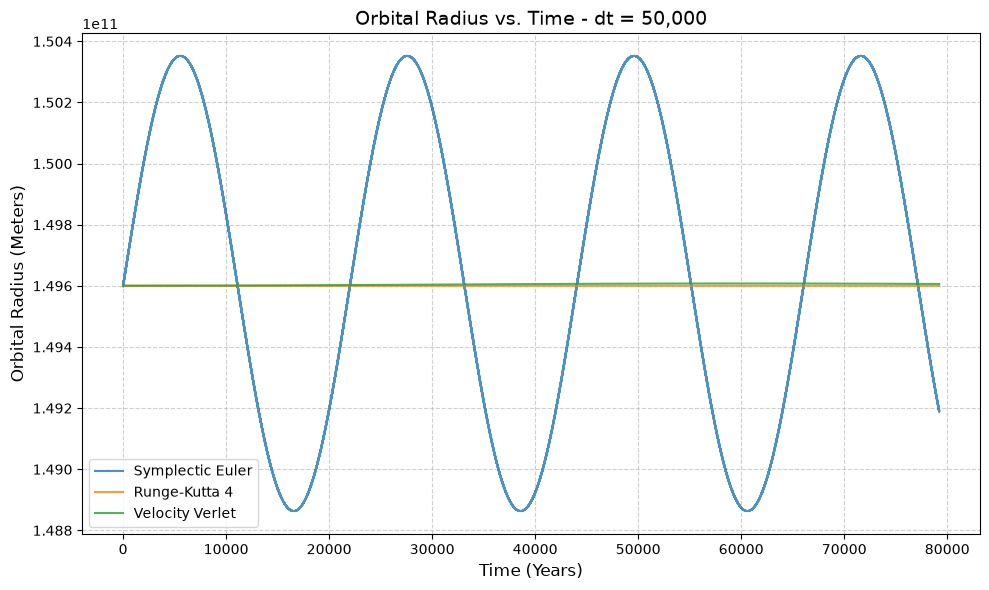

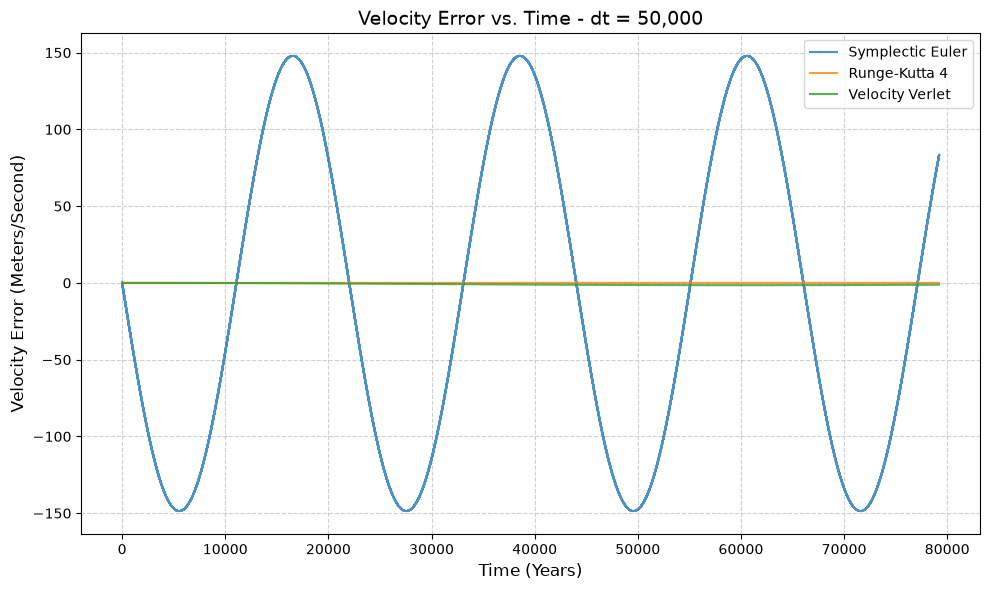

In [20]:
class TwoBodyDataAnalysis:

    def __init__(self):
        self.methods = {
            #'Forward Euler': pd.read_csv('results/forward_euler_diagnostics_v2.csv'),
            'Symplectic Euler': pd.read_csv('results/symplectic_euler_diagnostics_v2.csv'),
            'Runge-Kutta 4': pd.read_csv('results/runge_kutta_4_diagnostics_v2.csv'),
            'Velocity Verlet': pd.read_csv('results/velocity_verlet_diagnostics_v2.csv'),
            #'Yoshida 4th-Order': pd.read_csv('results/yoshida_4th_order_diagnostics_v2.csv')
        }

    def plot_radius(self, use_log_scale=False, save=False):
        plt.figure(figsize=(10, 6))

        for name, df in self.methods.items():
            plt.plot(df['time_years'], df['radius_meters'],label=name,alpha=0.8)

        plt.title('Orbital Radius vs. Time - dt = 50,000', fontsize=14)
        plt.xlabel('Time (Years)', fontsize=12)
        plt.ylabel('Orbital Radius (Meters)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)

        if use_log_scale:
            plt.yscale('log')
            plt.ylabel('Orbital Radius (Meters) [Log Scale]', fontsize=12)

        plt.legend(loc='best')
        plt.tight_layout()

        if save:
            plt.savefig('radius_vs_time.png', dpi=300)

        plt.show()

    def plot_velocity_error(self, use_log_scale=False, save=False):
        plt.figure(figsize=(10, 6))

        for name, df in self.methods.items():
            plt.plot(df['time_years'], df['speed_error_m_per_s'],label=name,alpha=0.8)

        plt.title('Velocity Error vs. Time - dt = 50,000', fontsize=14)
        plt.xlabel('Time (Years)', fontsize=12)
        plt.ylabel('Velocity Error (Meters/Second)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)

        if use_log_scale:
            plt.yscale('log')
            plt.ylabel('Velocity Error (Meters/Second) [Log Scale]', fontsize=12)

        plt.legend(loc='best')
        plt.tight_layout()

        if save:
            plt.savefig('velocity_error_vs_time.png', dpi=300)

        plt.show()

analysis = TwoBodyDataAnalysis()
analysis.plot_radius()
analysis.plot_velocity_error()

Currently, the architecture of the project works by iterating through and body at each step, and then iterating through each body again to calculate the forces acting on all of them and in turn calculate the new positions and velocities via one of the integrators (Forward Euler, Symplectic Euler, Runge-Kutta 4, Velocity Verlet, Yoshida 4th-Order). It then repeats this for each step until it is complete, at which point it returns an array of each position at each step, the final positions, and the maximum and minimums of energy and linear and angular momentum.

This data can then be either visualized with matplotlib to show a trajectory or compared via other results. To compare with other results there is two_simulation_position_comparison that will compare one integrator with another where each may have a different time step size with the same ending time, or there is horizon_data_position_comparison, that takes an initial start time in a readable format for JPL Horizons, computes the end time based on the steps and step size, then compares the ending position of the simulation to what JPL Horizons has recorded for that time.

This simulation currently only has the sun and the eight planets and uses barycentric coordinates, treating the sun as a dynamical body. Masses for each planet are currently imprecise, increasing error when compared with Horizons data. Initial positions and velocities are assigned via the set_positions_at_time method.

For a brief verification, we will conduct a two-body test using Earth and the Sun, giving Earth a circular orbit such that $v=\sqrt{\frac{GM}{r}}$ and $T=2\pi\sqrt{\frac{r^3}{GM}}$. We will compare the known analytical solutions to the simulation results to compare integrator accuracy.